# 📋 Linear Regression Project — Cheat Sheet
A quick-reference companion to the PSID earnings project. Organized by workflow stage,
with runnable mini-examples against `psid_2017.csv` so every snippet is demonstrably
correct — copy, paste, adapt.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy import stats

sns.set_theme(style="whitegrid")
df = pd.read_csv("psid_2017.csv", index_col=0)
df.shape


(26445, 9)

---
## 1. Loading & First Look

| Task | R (course syntax) | Python equivalent |
|---|---|---|
| Load CSV | `read.csv('file.csv', header=T)` | `pd.read_csv('file.csv')` |
| Structure/types | `str(df)` | `df.info()` |
| Summary stats | `summary(df)` | `df.describe(include='all')` |
| Column mean | `mean(df$col)` | `df['col'].mean()` |
| First rows | `head(df)` | `df.head()` |

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26445 entries, 1 to 26445
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   X                26445 non-null  int64
 1   gender           26445 non-null  int64
 2   age              26445 non-null  int64
 3   married          26445 non-null  int64
 4   employed         18221 non-null  str  
 5   educated_in_us   26445 non-null  int64
 6   highest_degree   26445 non-null  str  
 7   education_years  26445 non-null  int64
 8   labor_income     26445 non-null  int64
dtypes: int64(7), str(2)
memory usage: 1.8 MB


In [3]:
df.describe(include='all').T.head(10)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
X,26445.0,NaN,NaN,NaN,13223.0,7634.158271,1.0,6612.0,13223.0,19834.0,26445.0
gender,26445.0,NaN,NaN,NaN,1.52059,0.499585,1.0,1.0,2.0,2.0,2.0
age,26445.0,NaN,NaN,NaN,34.320514,47.133137,1.0,14.0,30.0,48.0,999.0
married,26445.0,NaN,NaN,NaN,0.386538,0.493292,0.0,0.0,0.0,1.0,3.0
employed,18221,8,employed,11723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
educated_in_us,26445.0,NaN,NaN,NaN,0.974589,1.392453,0.0,0.0,1.0,1.0,9.0
highest_degree,26445,9,no college,20892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_years,26445.0,NaN,NaN,NaN,10.413802,13.022874,0.0,0.0,12.0,14.0,99.0
labor_income,26445.0,NaN,NaN,NaN,1375.459822,7646.515974,0.0,0.0,0.0,0.0,370500.0


---
## 2. Handling Missing / Sentinel Codes

Survey data often encodes "missing" as an out-of-range number (999, 99, -9, etc.)
instead of a blank. **Always check `.describe()` / `.unique()` for suspicious max/min
values before trusting a column.**

In [4]:
# Spot a sentinel code
print(sorted(df['age'].unique())[-5:])   # -> ... 999 stands out
print(sorted(df['education_years'].unique())[-3:])  # -> ... 99 stands out


[np.int64(99), np.int64(100), np.int64(101), np.int64(103), np.int64(999)]
[np.int64(16), np.int64(17), np.int64(99)]


In [5]:
# Replace sentinel codes with NaN (do this BEFORE any stats/plots)
df_clean = df.copy()
df_clean['age'] = df_clean['age'].replace(999, np.nan)
df_clean['education_years'] = df_clean['education_years'].replace(99, np.nan)

# General pattern for multiple codes at once:
# df_clean['col'] = df_clean['col'].replace([98, 99, -9], np.nan)

df_clean[['age', 'education_years']].isna().sum()


age                 50
education_years    420
dtype: int64

**Common missing-data pitfalls:**
- A `NaN` string of text (`"NA"`) reads in as an actual string, not a null — check with `df['col'].apply(type).unique()`.
- Don't assume 0 means "none" — it might mean "not applicable" or "not asked" (see Section 3).
- Drop rows with `.dropna(subset=[...])` only *after* deciding which missingness is random vs. structural.

---
## 3. Structural vs. Random Zeros/Missingness

Before filtering "outliers" or "missing" values, ask **why** a value looks strange.
A cheap diagnostic: cross-tabulate the suspicious variable against a related variable.

In [6]:
# Is labor_income == 0 spread randomly, or concentrated in a specific group?
check = df_clean[(df_clean['age'] >= 25) & (df_clean['age'] <= 65)]
pd.crosstab(check['employed'], check['labor_income'] == 0, normalize='index').round(2)


labor_income,False,True
employed,,
disabled,0.01,0.99
employed,0.08,0.92
furlough,0.05,0.95
keeping house,0.02,0.98
other,0.30,0.70
retired,0.02,0.98
student,0.06,0.94
unemployed,0.08,0.92


If a supposedly continuous variable is exactly 0 for the *overwhelming majority* of an
otherwise-eligible subgroup (like `employed == 'employed'` people above), suspect a
**structural/reporting artifact** rather than genuine zero values, and consider filtering
to the subpopulation where the variable is actually measured.

---
## 4. Filtering & Recoding

In [7]:
# Filter rows on a numeric range
sub = df_clean[(df_clean['age'] >= 25) & (df_clean['age'] <= 65)]

# Filter on a condition + drop remaining NAs
sub = sub[sub['labor_income'] > 0].dropna(subset=['education_years'])

# Recode a numeric code to a label
sub = sub.copy()
sub['gender_label'] = sub['gender'].map({1: 'Male', 2: 'Female'})

# Recode with a dictionary + collapse many categories into few
degree_map = {
    'no college': 'No college', 'other': 'No college',
    'associate': 'Some college', 'bachelor': 'Some college',
    'master': 'Graduate', 'doctorate': 'Graduate',
    'juris doctorate': 'Graduate', 'medical degree': 'Graduate',
}
sub['degree_tier'] = sub['highest_degree'].map(degree_map)  # unmapped -> NaN

# Binary flag from a condition
sub['is_married'] = (sub['married'] == 1).astype(int)

sub[['gender_label', 'degree_tier', 'is_married']].head()


,gender_label,degree_tier,is_married
27,Male,No college,0
32,Male,No college,0
115,Female,Some college,0
122,Male,No college,0
129,Female,No college,0


---
## 5. Checking the Linearity Assumption

In [8]:
# Correlation coefficient (R's cor.test() equivalent)
r, p = stats.pearsonr(sub['education_years'], sub['labor_income'])
print(f"r = {r:.3f}, p = {p:.2e}")

# Rule of thumb for |r|:
#   0.8-1.0 very strong | 0.6-0.8 strong | 0.4-0.6 moderate | <0.4 weak


r = -0.025, p = 4.55e-01


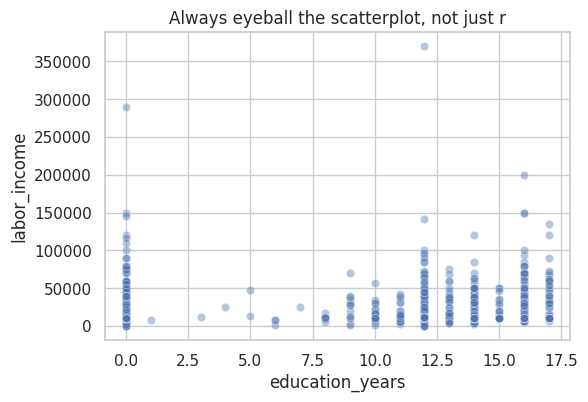

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=sub, x='education_years', y='labor_income', alpha=0.4, ax=ax)
ax.set_title('Always eyeball the scatterplot, not just r')
plt.show()


**Log-transform when the outcome is skewed** (typical for income, price, counts):

In [10]:
sub = sub.copy()
sub['log_income'] = np.log(sub['labor_income'])
print('Raw skew:', sub['labor_income'].skew().round(2))
print('Log skew:', sub['log_income'].skew().round(2))
# Rule of thumb: |skew| < ~0.5 is roughly symmetric; > 1 is strongly skewed


Raw skew: 4.67
Log skew: -0.87


---
## 6. Outlier Detection (IQR / Boxplot Method)

In [11]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

lo, hi = iqr_bounds(sub['log_income'])
outliers = (sub['log_income'] < lo) | (sub['log_income'] > hi)
print(f"Bounds: [{lo:.2f}, {hi:.2f}]  ->  {outliers.sum()} outliers")

clean = sub[~outliers]


Bounds: [7.62, 12.07]  ->  21 outliers


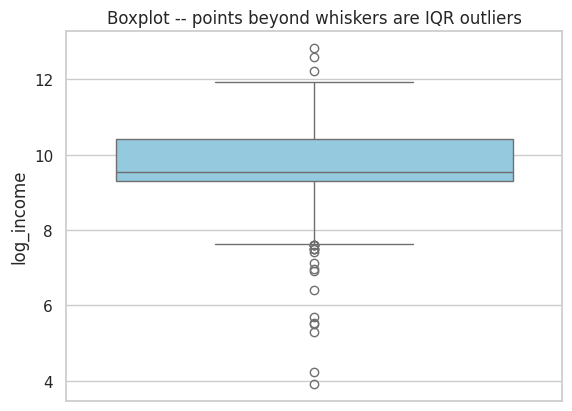

In [12]:
sns.boxplot(y=sub['log_income'], color='skyblue')
plt.title('Boxplot -- points beyond whiskers are IQR outliers')
plt.show()


---
## 7. Train/Test Split

In [13]:
train, test = train_test_split(clean, test_size=0.2, random_state=42)
print(len(train), len(test))


688 172


---
## 8. Fitting Models

| Task | R | Python (`statsmodels.formula.api`) |
|---|---|---|
| Simple regression | `lm(y ~ x, data=train)` | `smf.ols('y ~ x', data=train).fit()` |
| Multiple regression | `lm(y ~ x1 + x2, data=train)` | `smf.ols('y ~ x1 + x2', data=train).fit()` |
| Categorical predictor | (factor auto-detected) | `smf.ols('y ~ C(cat_col)', data=train).fit()` |
| Polynomial term | `lm(y ~ x + I(x^2))` | `smf.ols('y ~ x + I(x**2)', data=train).fit()` — or add a precomputed column |
| Model summary | `summary(model)` | `print(model.summary())` |

In [14]:
model = smf.ols('log_income ~ education_years', data=train).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:             log_income   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                   0.09665
Date:                Sat, 22 Aug 2026   Prob (F-statistic):              0.756
Time:                        14:41:09   Log-Likelihood:                -795.14
No. Observations:                 688   AIC:                             1594.
Df Residuals:                     686   BIC:                             1603.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           9.8502      0.064    1

---
## 9. Model Fit Statistics

In [15]:
print('R-squared:        ', model.rsquared)
print('Adj. R-squared:   ', model.rsquared_adj)
print('RSE (resid. std): ', np.sqrt(model.mse_resid))
print('AIC / BIC:        ', model.aic, model.bic)


R-squared:         0.00014087593818901123
Adj. R-squared:    -0.001316644650822374
RSE (resid. std):  0.7696980237650862
AIC / BIC:         1594.278852320432 1603.3464299962986


**Quick guide:**
- **R²**: % of outcome variance explained. Higher is better, but always compare to a
  sensible baseline — R² of 0.1 can still be a genuinely useful model for noisy human
  behavior data.
- **Adjusted R²**: like R² but penalizes extra predictors — use this (not raw R²) when
  comparing models with different numbers of predictors.
- **RSE / RMSE**: typical prediction error, in the outcome's own units — easier to
  explain to non-technical stakeholders than R².
- **AIC / BIC**: lower is better; useful for comparing non-nested models.

---
## 10. Residual Diagnostics

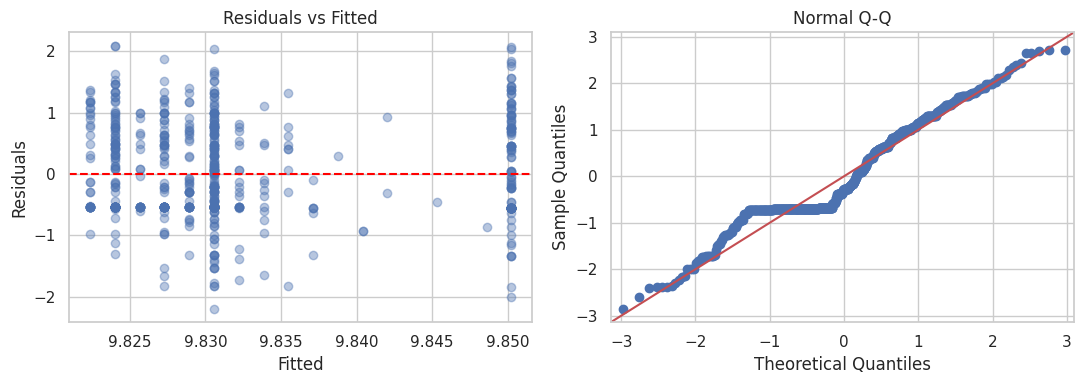

In [16]:
fitted, resid = model.fittedvalues, model.resid

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(fitted, resid, alpha=0.4)
axes[0].axhline(0, color='red', ls='--')
axes[0].set(xlabel='Fitted', ylabel='Residuals', title='Residuals vs Fitted')
sm.qqplot(resid, line='45', fit=True, ax=axes[1])
axes[1].set_title('Normal Q-Q')
plt.tight_layout(); plt.show()


**What to look for:**
| Pattern | Diagnosis |
|---|---|
| Random scatter around 0, constant spread | ✅ Assumptions look OK |
| "Funnel" shape (spread grows with fitted value) | Heteroscedasticity — try a log/Box-Cox transform |
| Curve/bow shape | Missing non-linear term (e.g., add `x**2`) |
| Q-Q points depart from the line at the tails | Non-normal residuals (income/price data often does this — usually OK for large samples, but be cautious with small-sample p-values) |

---
## 11. Visualizing Fit

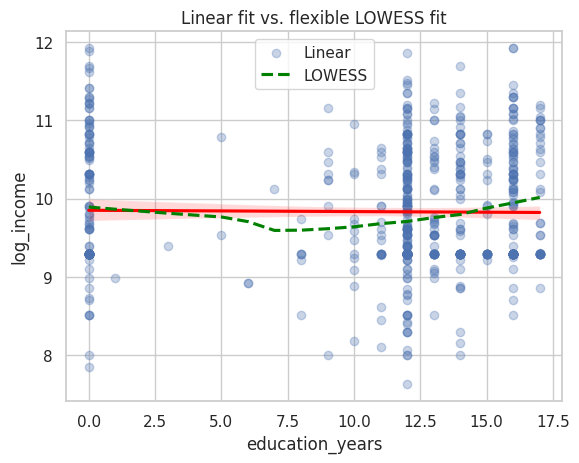

In [17]:
sns.regplot(data=train, x='education_years', y='log_income',
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'}, label='Linear')
sns.regplot(data=train, x='education_years', y='log_income', scatter=False,
            lowess=True, line_kws={'color': 'green', 'ls': '--'}, label='LOWESS')
plt.legend(); plt.title('Linear fit vs. flexible LOWESS fit'); plt.show()


---
## 12. Interpreting Coefficients

In [18]:
beta = model.params['education_years']
ci_low, ci_high = model.conf_int().loc['education_years']
pval = model.pvalues['education_years']
print(f"beta = {beta:.4f}, 95% CI [{ci_low:.4f}, {ci_high:.4f}], p = {pval:.2e}")

# If outcome is log(y): coefficient -> approx. percentage effect
pct = (np.exp(beta) - 1) * 100
print(f"~{pct:.1f}% change in y per +1 unit of x")


beta = -0.0016, 95% CI [-0.0120, 0.0087], p = 7.56e-01
~-0.2% change in y per +1 unit of x


**Interpretation cheat sheet:**
| Model form | Coefficient meaning |
|---|---|
| `y ~ x` | +1 unit of x → +β units of y |
| `log(y) ~ x` | +1 unit of x → ~(e^β − 1)×100% change in y |
| `y ~ log(x)` | +1% change in x → ~(β/100) unit change in y |
| `log(y) ~ log(x)` | +1% change in x → ~β% change in y (elasticity) |
| `y ~ C(category)` | each level's β is the difference vs. the left-out **reference level** |
| p-value < 0.05 | reject "no linear relationship" null at the 5% level |
| 95% CI excludes 0 | consistent with a statistically significant effect |

---
## 13. Predicting & Evaluating

In [19]:
test = test.copy()
test['pred'] = model.predict(test)

print('Test R2:  ', r2_score(test['log_income'], test['pred']))
print('Test RMSE:', np.sqrt(mean_squared_error(test['log_income'], test['pred'])))

# Always compare against a naive baseline!
baseline = np.full(len(test), train['log_income'].mean())
print('Baseline RMSE:', np.sqrt(mean_squared_error(test['log_income'], baseline)))


Test R2:   -0.0024631602649849427
Test RMSE: 0.7041822867770338
Baseline RMSE: 0.7042659868294266


---
## 14. Multiple Regression Extras

In [20]:
# Nested model comparison (does adding predictors significantly help?)
model_multi = smf.ols('log_income ~ education_years + age', data=train).fit()
anova_lm(model, model_multi)


,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,686.0,406.410443,0.0,NaN,NaN,NaN
1,685.0,396.359429,1.0,10.051014,17.370457,0.000035


In [21]:
# Multicollinearity check (VIF). Rule of thumb: VIF > 5-10 is concerning.
X = sm.add_constant(train[['education_years', 'age']].astype(float))
pd.DataFrame({
    'variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})


,variable,VIF
0,const,59.524075
1,education_years,2.578722
2,age,2.578722


---
## 15. Common Pitfalls Checklist

- [ ] Checked `.describe()` / `.unique()` for sentinel missing-value codes before modeling
- [ ] Investigated *why* zeros/outliers exist before deleting them (structural vs. random)
- [ ] Visualized the x–y relationship, not just the correlation number
- [ ] Checked and treated skew in the outcome variable (log transform if needed)
- [ ] Held out a test set before evaluating predictive performance
- [ ] Checked residual plots, not just R²
- [ ] Used adjusted R² (not raw R²) when comparing models with different predictor counts
- [ ] Checked VIF before trusting individual coefficients in a multiple regression
- [ ] Stated the correct reference category when interpreting categorical coefficients
- [ ] Did NOT claim causation from an observational regression coefficient
- [ ] Stated who the analytic sample actually represents (generalizability)